In [ ]:
# -<Python STD>-
import numpy as np
import pandas as pd
import sys
import os


# -<Data Formatting>-
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import SimpleImputer
from scipy.spatial.distance import pdist
from pyefd import elliptic_fourier_descriptors


# -<Information Analysis>-
import umap.umap_ as umap
from scipy.fftpack import dct
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from shapely.geometry import Polygon, LineString


# -<Visualizing correlations>-
from pandas.plotting import scatter_matrix
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sb


# --<Machine Learning: Clustering>--
import torch
import hdbscan
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import adjusted_rand_score, silhouette_score, davies_bouldin_score
from sklearn.cluster import SpectralClustering
from sklearn.cluster import KMeans


# -<Do not be annoying>
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module='statsmodels')
warnings.filterwarnings("ignore", category=FutureWarning, module='statsmodels')

/home/molderon/micromamba/envs/Kaon/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
class HystProcessor:
    def __init__(self, file_destinations):
        self.file_destinations = file_destinations
        self.SAMPLE_RATE_MS = 20
        self.MIN_LENGTH_READINGS = 100
        self.POST_BREATH_BUFFER = 5


    def load_npy(self, filename, description="data"):
        try:
            data = np.load(filename)
            print(f"Successfully loaded {filename}. Shape: {data.shape}")
            return data
        except FileNotFoundError:
            print(f" ERROR: Required {description} file ('{filename}') not found. ")
            sys.exit(1)
        except Exception as e:
            print(f" ERROR: Failed to load {filename}. Details: {e} ")
            sys.exit(1)


    def ComputeDuration(self, flow_arr, pressure_arr):
        lengths = []
        num_breaths, num_timesteps = flow_arr.shape
        for i in range(num_breaths):
            PaddingFound = np.logical_and(flow_arr[i] == 0, pressure_arr[i] == 0)
            last_true_index = np.where(~PaddingFound)[0]
            if last_true_index.size == 0:
                length = 0
            else:
                length = last_true_index[-1] + 1
            lengths.append(length)
        return np.array(lengths)


    def check_preprocessed_data(self):
        csv_path = self.file_destinations.get('output_csv')
        if csv_path and os.path.exists(csv_path):
            print(f"Existing processed file found at {csv_path}. Loading...")
            return pd.read_csv(csv_path)
        return None


    def process(self, save_output=False):
        cached_df = self.check_preprocessed_data()
        if cached_df is not None:
            return cached_df

        print("No processed file found. Starting processing from .npy files...")
        
        flow = self.load_npy(self.file_destinations['flow'], 'Flow Time Series')
        pressure = self.load_npy(self.file_destinations['pressure'], 'Pressure Time Series')
        trainy = self.load_npy(self.file_destinations['trainy'], 'One-Hot Target')

        InitCycle_C, num_timesteps = flow.shape
        if pressure.shape != (InitCycle_C, num_timesteps):
            print(" ERROR: Flow and Pressure array shapes do not match. ")
            sys.exit(1)
        if trainy.shape[0] != InitCycle_C:
            print(f" ERROR: Target values row count ({trainy.shape[0]}) does not match the number of breaths ({InitCycle_C}). ")
            sys.exit(1)

        num_classes = trainy.shape[1]
        print(f"\nInitial Data structural check passed. Total breaths: {InitCycle_C}, Timesteps (padded): {num_timesteps}, Classes: {num_classes}")

        true_lengths = self.ComputeDuration(flow, pressure)
        print(f"\nInferred true lengths for {len(true_lengths)} breaths.")

        ValidCycles = np.where(true_lengths >= self.MIN_LENGTH_READINGS)[0]
        print(f"Filtering: Keeping {len(ValidCycles)} breaths with length >= {self.MIN_LENGTH_READINGS} readings.")

        flow_filtered = flow[ValidCycles]
        pressure_filtered = pressure[ValidCycles]
        trainy_filtered = trainy[ValidCycles]
        true_lengths_filtered = true_lengths[ValidCycles]

        num_breaths_final = len(ValidCycles)
        all_data = []

        for i in range(num_breaths_final):
            breath_id = ValidCycles[i]
            length = true_lengths_filtered[i]
            end_index = min(length + self.POST_BREATH_BUFFER, num_timesteps)

            flow_slice = flow_filtered[i, :end_index]
            pressure_slice = pressure_filtered[i, :end_index]
            num_points = end_index

            time_ms = np.arange(num_points) * self.SAMPLE_RATE_MS
            targets = np.tile(trainy_filtered[i], (num_points, 1))

            temp_df = pd.DataFrame({
                'Breath_ID': breath_id,
                'Time_Step': np.arange(num_points),
                'Time_ms': time_ms,
                'Flow': flow_slice,
                'Pressure': pressure_slice,
            })

            temp_df[[f'Target_Class_{c}' for c in range(num_classes)]] = targets
            all_data.append(temp_df)

        df_processed = pd.concat(all_data, ignore_index=True)

        print("\n Final Processed DataFrame Head (Filtered and Truncated) ")
        print(f"Final Data Shape: {df_processed.shape}")
        
        if save_output and 'output_csv' in self.file_destinations:
            output_file = self.file_destinations['output_csv']
            df_processed.to_csv(output_file, index=False)
            print(f"\n✅ Final, combined dataset saved to '{output_file}'.")

        return df_processed

config_destinations = {
    'flow': 'flow.npy',
    'pressure': 'pressure.npy',
    'trainy': 'trainy_all.npy',
    'output_csv': 'PAV_dataset.csv'
}

processor = HystProcessor(config_destinations)
Dataset = processor.process(save_output=True)

Existing processed file found at PAV_dataset.csv. Loading...


In [5]:
Dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1272587 entries, 0 to 1272586
Data columns (total 10 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   Breath_ID       1272587 non-null  int64  
 1   Time_Step       1272587 non-null  int64  
 2   Time_ms         1272587 non-null  int64  
 3   Flow            1272587 non-null  float64
 4   Pressure        1272587 non-null  float64
 5   Target_Class_0  1272587 non-null  int64  
 6   Target_Class_1  1272587 non-null  int64  
 7   Target_Class_2  1272587 non-null  int64  
 8   Target_Class_3  1272587 non-null  int64  
 9   Target_Class_4  1272587 non-null  int64  
dtypes: float64(2), int64(8)
memory usage: 97.1 MB


In [6]:
class StaticFeatureExtraction:
    def __init__(self, num_efd_harmonics=10, num_dct_coeffs=10):
        self.num_harmonics = num_efd_harmonics
        self.num_dct_coeffs = num_dct_coeffs

    def extract_all(self, df):
        feature_list = []
        for breath_id, group in df.groupby('Breath_ID'):
            # Ensure the loop is closed for geometric calculations
            x = group['Flow'].values
            y = group['Pressure'].values
            
            # 1. Loop Area (Shoelace Formula) / Hysteresis Loss Integral
            area = 0.5 * np.abs(np.dot(x, np.roll(y, 1)) - np.dot(y, np.roll(x, 1)))
            
            # 2. Coercivity and Remanence Equivalents
            # x-intercepts (where y is near zero) and y-intercepts (where x is near zero)
            rem_eq = np.mean(np.abs(y[np.isclose(x, 0, atol=0.1)])) if any(np.isclose(x, 0, atol=0.1)) else 0
            coer_eq = np.mean(np.abs(x[np.isclose(y, 0, atol=0.1)])) if any(np.isclose(y, 0, atol=0.1)) else 0
            
            # 3. Aspect Ratio (via PCA-lite: bounding box of rotated coords)
            dx = np.max(x) - np.min(x)
            dy = np.max(y) - np.min(y)
            aspect_ratio = dx / dy if dy != 0 else 0
            
            # 4. Curvature with Frenet-Serret formula (approximate)
            # kappa = |x'y'' - y'x''| / (x'^2 + y'^2)^(1.5)
            dx_dt = np.gradient(x)
            dy_dt = np.gradient(y)
            d2x_dt2 = np.gradient(dx_dt)
            d2y_dt2 = np.gradient(dy_dt)
            curvature = np.abs(dx_dt * d2y_dt2 - dy_dt * d2x_dt2) / (dx_dt**2 + dy_dt**2 + 1e-6)**1.5
            mean_curvature = np.mean(curvature)
            
            # 5. Elliptic Fourier Descriptors (EFD)
            coeffs = elliptic_fourier_descriptors(np.column_stack([x, y]), order=self.num_harmonics, normalize=True)
            efd_flattened = coeffs.flatten()
            
            # 6. Discrete Cosine Transform (DCT)
            dct_x = dct(x, type=2, norm='ortho')[:self.num_dct_coeffs]
            dct_y = dct(y, type=2, norm='ortho')[:self.num_dct_coeffs]
            
            # 7. Phase Velocity (average angular velocity around centroid)
            x_c, y_c = x - np.mean(x), y - np.mean(y)
            angles = np.arctan2(y_c, x_c)
            phase_velocity = np.mean(np.abs(np.gradient(np.unwrap(angles))))

            # Assemble features
            feat_dict = {
                'Breath_ID': breath_id,
                'Loop_Area': area,
                'Remanence_Eq': rem_eq,
                'Coercivity_Eq': coer_eq,
                'Aspect_Ratio': aspect_ratio,
                'Mean_Curvature': mean_curvature,
                'Phase_Velocity': phase_velocity
            }
            
            # Add EFD and DCT entries
            for i, val in enumerate(efd_flattened): feat_dict[f'EFD_{i}'] = val
            for i, val in enumerate(dct_x): feat_dict[f'DCT_X_{i}'] = val
            for i, val in enumerate(dct_y): feat_dict[f'DCT_Y_{i}'] = val
            
            feature_list.append(feat_dict)
            
        return pd.DataFrame(feature_list)

In [7]:
StaticFeatures = StaticFeatureExtraction()
Static_df = StaticFeatures.extract_all(Dataset)
Static_df.info()

/home/molderon/micromamba/envs/Kaon/lib/python3.12/site-packages/pyefd.py:67: RuntimeWarning: invalid value encountered in divide
  a = consts * np.sum((dxy[:, 0] / dt) * d_cos_phi, axis=1)
/home/molderon/micromamba/envs/Kaon/lib/python3.12/site-packages/pyefd.py:68: RuntimeWarning: invalid value encountered in divide
  b = consts * np.sum((dxy[:, 0] / dt) * d_sin_phi, axis=1)
/home/molderon/micromamba/envs/Kaon/lib/python3.12/site-packages/pyefd.py:69: RuntimeWarning: invalid value encountered in divide
  c = consts * np.sum((dxy[:, 1] / dt) * d_cos_phi, axis=1)
/home/molderon/micromamba/envs/Kaon/lib/python3.12/site-packages/pyefd.py:70: RuntimeWarning: invalid value encountered in divide
  d = consts * np.sum((dxy[:, 1] / dt) * d_sin_phi, axis=1)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7736 entries, 0 to 7735
Data columns (total 67 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Breath_ID       7736 non-null   int64  
 1   Loop_Area       7736 non-null   float64
 2   Remanence_Eq    7736 non-null   float64
 3   Coercivity_Eq   7736 non-null   float64
 4   Aspect_Ratio    7736 non-null   float64
 5   Mean_Curvature  7736 non-null   float64
 6   Phase_Velocity  7736 non-null   float64
 7   EFD_0           0 non-null      float64
 8   EFD_1           0 non-null      float64
 9   EFD_2           0 non-null      float64
 10  EFD_3           0 non-null      float64
 11  EFD_4           0 non-null      float64
 12  EFD_5           0 non-null      float64
 13  EFD_6           0 non-null      float64
 14  EFD_7           0 non-null      float64
 15  EFD_8           0 non-null      float64
 16  EFD_9           0 non-null      float64
 17  EFD_10          0 non-null      f

In [8]:
class StreamlinedPCA:
    def __init__(self, n_components=10):
        self.n_components = n_components
        self.pca = PCA(n_components=n_components)
        self.loadings = None
        self.feature_names = None

    def fit_transform(self, data):
        self.feature_names = data.columns.tolist()
        transformed_data = self.pca.fit_transform(data)
        
        self.loadings = pd.DataFrame(
            self.pca.components_.T,
            columns=[f'PC{i+1}' for i in range(self.pca.n_components_)],
            index=self.feature_names
        )
        return transformed_data

    def plot_variance(self):
        plt.figure(figsize=(10, 6))
        exp_var = self.pca.explained_variance_ratio_
        cum_var = np.cumsum(exp_var)
        
        bars = plt.bar(range(1, len(exp_var) + 1), exp_var, alpha=0.8, color='skyblue', label='Individual')
        plt.plot(range(1, len(exp_var) + 1), cum_var, marker='o', linestyle='--', color='salmon', label='Cumulative')

        for i, (bar, cv) in enumerate(zip(bars, cum_var)):
            plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{exp_var[i]:.3f}', ha='center', va='bottom')
            plt.text(i + 1, cv, f'{cv:.3f}', ha='center', va='bottom')

        plt.title('Explained Variance by Principal Component')
        plt.xlabel('PC Number'); plt.ylabel('Variance Ratio'); plt.legend(); plt.grid(True)
        plt.tight_layout()
        plt.show()

    def plot_loadings_heatmap(self, n_pcs=5):
        plt.figure(figsize=(12, 8))
        sorted_loadings = self.loadings.sort_values(by='PC1', ascending=False)
        sb.heatmap(sorted_loadings.iloc[:, :n_pcs], annot=True, cmap='viridis', fmt=".3f")
        plt.title(f'Feature Loadings (Top {n_pcs} PCs)')
        plt.tight_layout(); plt.show()

    def run_kaiser_threshold(self):
        eigenvalues = self.pca.explained_variance_
        above_threshold = eigenvalues > 1
        
        results_df = pd.DataFrame({
            'Eigenvalue': eigenvalues,
            'Above_Kaiser': above_threshold,
            'Var_Explained': self.pca.explained_variance_ratio_,
            'Cum_Var': np.cumsum(self.pca.explained_variance_ratio_)
        }, index=[f'PC-{i+1}' for i in range(len(eigenvalues))])

        print("\n--- Kaiser-Guttman Analysis ---")
        print(results_df)
        
        significant_pcs = results_df[results_df['Above_Kaiser']].index.tolist()
        for pc in significant_pcs:
            top_3 = self.loadings[pc.replace('-', '')].abs().sort_values(ascending=False).head(3)
            print(f"\nTop 3 for {pc}:")
            for feat in top_3.index:
                print(f"  - {feat}: {self.loadings.loc[feat, pc.replace('-', '')]:.4f}")

Dropped 40 constant features (zero variance).


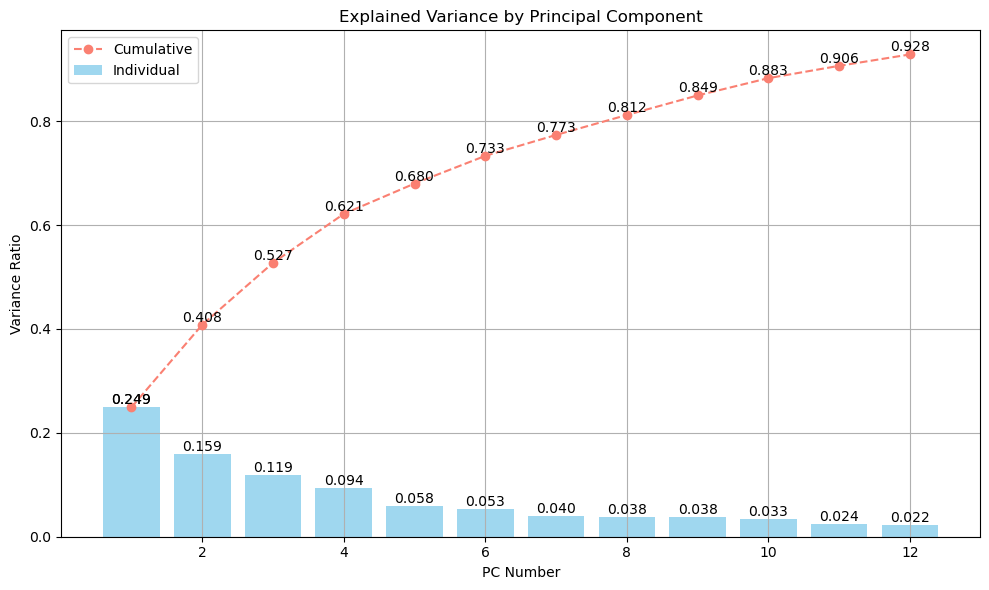


--- Kaiser-Guttman Analysis ---
       Eigenvalue  Above_Kaiser  Var_Explained   Cum_Var
PC-1     6.478963          True       0.249159  0.249159
PC-2     4.132935          True       0.158938  0.408097
PC-3     3.097017          True       0.119101  0.527198
PC-4     2.450315          True       0.094231  0.621428
PC-5     1.518218          True       0.058385  0.679814
PC-6     1.386763          True       0.053330  0.733144
PC-7     1.046031          True       0.040227  0.773371
PC-8     0.998944         False       0.038416  0.811787
PC-9     0.978930         False       0.037646  0.849433
PC-10    0.864638         False       0.033251  0.882684
PC-11    0.617785         False       0.023758  0.906442
PC-12    0.569507         False       0.021901  0.928343

Top 3 for PC-1:
  - DCT_X_4: 0.3566
  - DCT_Y_7: -0.3303
  - DCT_Y_2: 0.3205

Top 3 for PC-2:
  - DCT_X_6: 0.4357
  - DCT_Y_5: 0.3623
  - DCT_Y_8: -0.3543

Top 3 for PC-3:
  - DCT_Y_1: 0.5078
  - Loop_Area: 0.4479
  - DCT_Y_4

In [9]:
# 1. Drop Breath_ID
Hyster_Features = Static_df.drop(columns=['Breath_ID'])

# 2. Filter out Constant Features (Variance = 0)
# We keep only columns where the standard deviation is not zero
constant_filter = Hyster_Features.std() > 0
Hyster_Features_Filtered = Hyster_Features.loc[:, constant_filter]

dropped_count = len(Hyster_Features.columns) - len(Hyster_Features_Filtered.columns)
print(f"Dropped {dropped_count} constant features (zero variance).")

# 3. Now Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(Hyster_Features_Filtered)
X_scaled_df = pd.DataFrame(X_scaled, columns=Hyster_Features_Filtered.columns)

# 4. Final Safety Check (Fill any remaining NaNs from calculation errors)
X_scaled_df = X_scaled_df.fillna(0)

# 5. Run PCA
spca = StreamlinedPCA(n_components=12)
X_pca = spca.fit_transform(X_scaled_df)

spca.plot_variance()
spca.run_kaiser_threshold()

In [10]:
import umap
import matplotlib.pyplot as plt
import seaborn as sns

def Umap_Analysis(pca_data, n_components_to_use=10, n_neighbors=40, min_dist=0.05):
    """
    pca_data: The X_pca output from your StreamlinedPCA
    n_components_to_use: 7 (based on your Kaiser-Guttman results)
    n_neighbors: Controls local vs global structure (40 is balanced for 7k samples)
    min_dist: Controls how tightly points are packed (0.05 allows for tight clusters)
    """
    
    # 1. Isolate the significant signal (PC1 to PC7)
    X_significant = pca_data[:, :n_components_to_use]
    
    # 2. Initialize UMAP
    reducer = umap.UMAP(
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        n_components=2, # 2D for visualization
        metric='euclidean',
        random_state=42 # For reproducibility
    )
    
    # 3. Fit and Transform
    print(f"Running UMAP on {X_significant.shape[0]} samples with {n_components_to_use} PCs...")
    umap_embedding = reducer.fit_transform(X_significant)
    
    # 4. Visualization
    plt.figure(figsize=(12, 9))
    
    # We use a scatter plot. Since we don't have clusters yet, 
    # we'll color by the 1st Principal Component to see the gradient.
    plt.scatter(
        umap_embedding[:, 0], 
        umap_embedding[:, 1], 
        s=2, 
        alpha=0.5, 
        cmap='viridis',
        c=X_significant[:, 0] # Color by PC1 (DCT/Frequency influence)
    )
    
    plt.title(f'UMAP Projection of Hysteresis Latent Space\n(Inputs: PC1-PC7, n_neighbors={n_neighbors}, min_dist={min_dist})')
    plt.xlabel('UMAP Dimension 1')
    plt.ylabel('UMAP Dimension 2')
    plt.colorbar(label='PC1 Magnitude (Frequency/Rhythm Component)')
    plt.grid(True, linestyle='--', alpha=0.6)
    
    plt.show()
    
    return umap_embedding

In [11]:
def Tsne_Analysis(pca_data, n_components_to_use=7, perplexity=40, learning_rate='auto'):
    
    # 1. Isolate the significant signal (PC1 to PC7)
    X_significant = pca_data[:, :n_components_to_use]
    
    # 2. Initialize t-SNE
    # init='pca' or 'learning_rate' makes it more stable
    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        learning_rate=learning_rate,
        init='pca',
        random_state=42,
        n_jobs=-1 # Use all available CPU cores
    )
    
    # 3. Fit and Transform
    print(f"Running t-SNE on {X_significant.shape[0]} samples with {n_components_to_use} PCs...")
    tsne_embedding = tsne.fit_transform(X_significant)
    
    # 4. Visualization
    plt.figure(figsize=(12, 9))
    
    # Color by PC3 (Loop_Area) this time to see a different geometric driver
    plt.scatter(
        tsne_embedding[:, 0], 
        tsne_embedding[:, 1], 
        s=3, 
        alpha=0.6, 
        cmap='magma',
        c=pca_data[:, 2] # PC3 index
    )
    
    plt.title(f't-SNE Projection of Hysteresis Latent Space\n(Inputs: PC1-PC7, Perplexity={perplexity})')
    plt.xlabel('t-SNE Dimension 1')
    plt.ylabel('t-SNE Dimension 2')
    plt.colorbar(label='PC3 Magnitude (Loop Area / Work Component)')
    plt.grid(True, linestyle=':', alpha=0.5)
    
    plt.show()
    
    return tsne_embedding

In [19]:
def run_hdbscan(embedding, min_cluster_size=50, min_samples=10):
   
    # 1. Initialize and Fit
    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=min_cluster_size,
        min_samples=min_samples,
        gen_min_span_tree=True,
        prediction_data=True
    )
    
    cluster_labels = clusterer.fit_predict(embedding)
    
    # 2. Visualization
    plt.figure(figsize=(12, 9))
    
    # -1 is the label for 'Noise' in HDBSCAN
    unique_labels = set(cluster_labels)
    colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]
    
    for k, col in zip(unique_labels, colors):
        if k == -1:
            col = [0, 0, 0, 1] # Black for noise
            label = "Noise"
        else:
            label = f"Cluster {k}"

        class_member_mask = (cluster_labels == k)
        xy = embedding[class_member_mask]
        plt.scatter(xy[:, 0], xy[:, 1], s=5, c=[col], label=label, alpha=0.6)

    plt.title(f'HDBSCAN Clustering on Latent Projection\nFound {len(unique_labels) - 1} Classes')
    plt.xlabel('Projection Dim 1'); plt.ylabel('Projection Dim 2')
    plt.legend(markerscale=3, loc='best')
    plt.show()
    
    return cluster_labels, clusterer

Running UMAP on 7736 samples with 12 PCs...


/home/molderon/micromamba/envs/Kaon/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


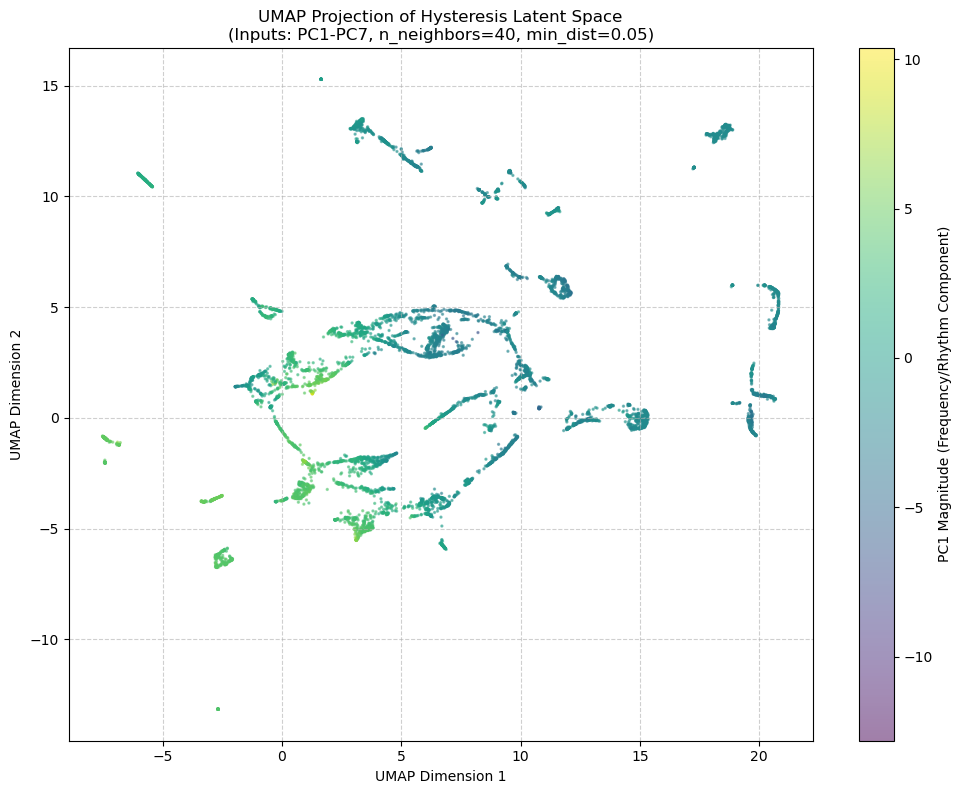

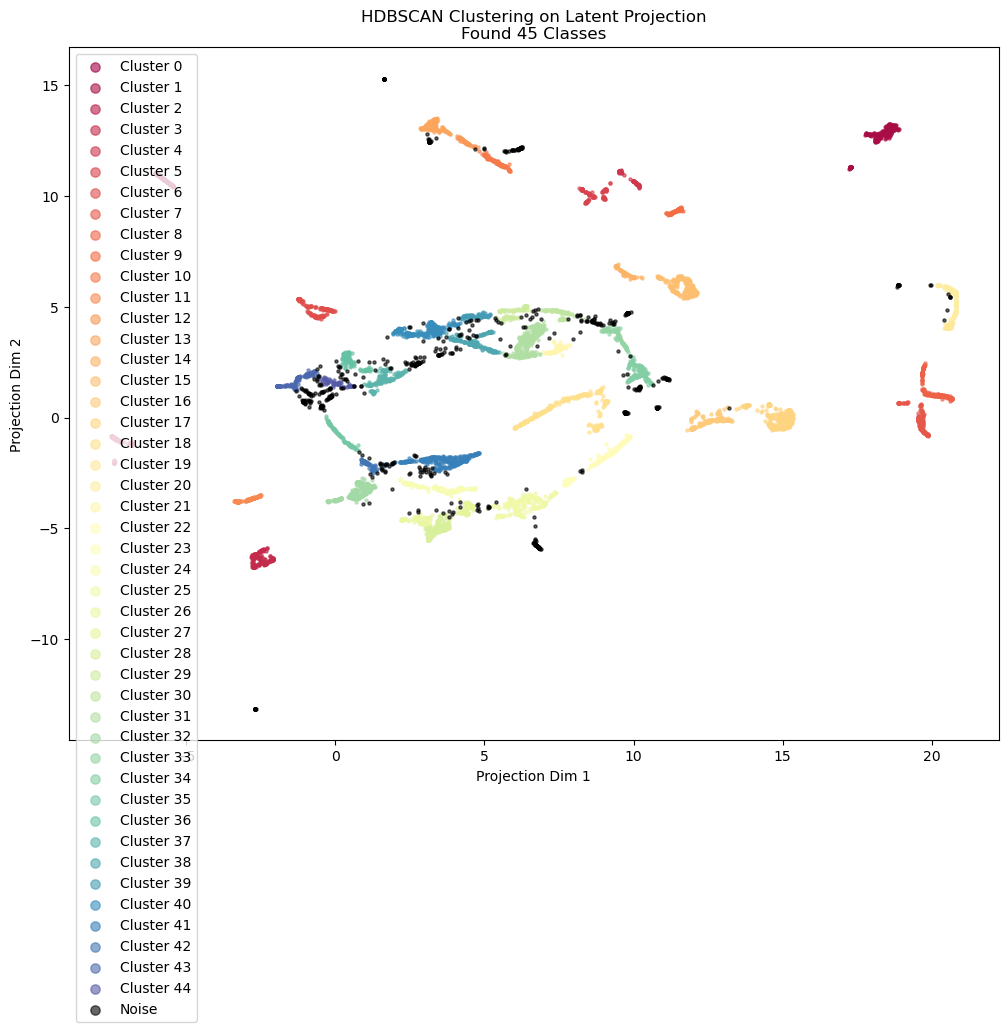

In [20]:
labels, model = run_hdbscan(Umap_Analysis(X_pca, n_components_to_use=12), min_cluster_size=60)

Running t-SNE on 7736 samples with 12 PCs...


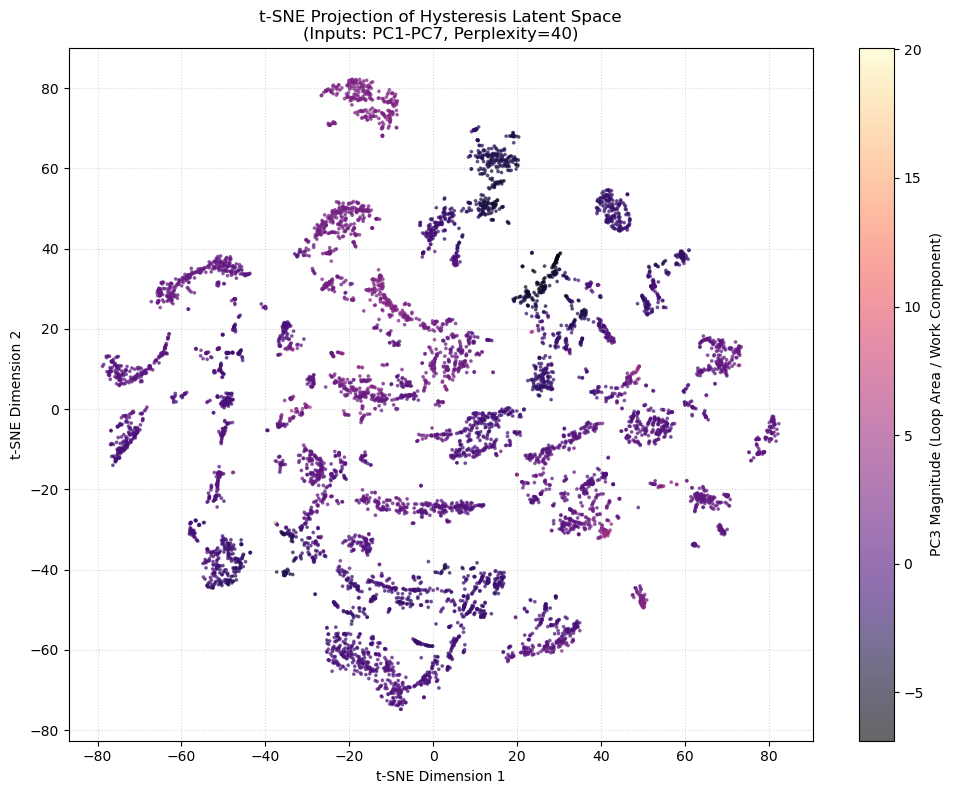

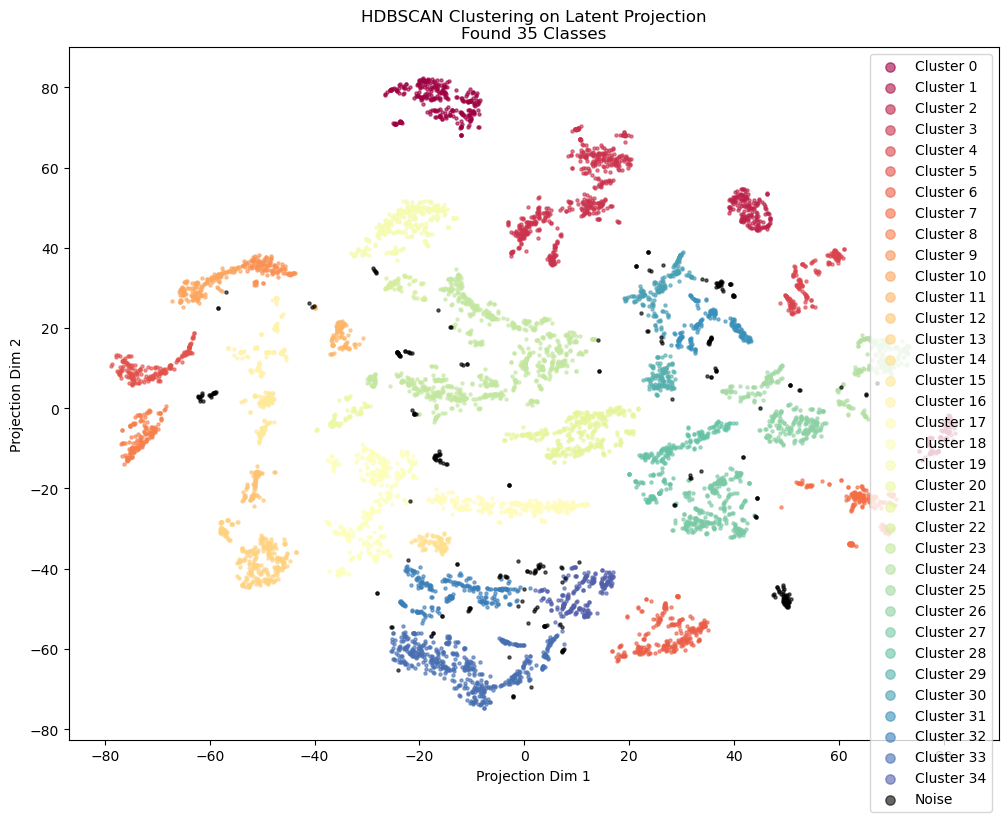

In [21]:
labels, model = run_hdbscan(Tsne_Analysis(X_pca, n_components_to_use=12), min_cluster_size=60)

> Maybe we could try with Self-Organazing Maps, Spectral Clustering ?

# Respiratory Waveform Clustering Pipeline Documentation

This documentation describes the architecture and workflow of the `BreathClusteringPipeline`. This system is designed for the unsupervised discovery of breathing patterns (phenotypes) from mechanical ventilation data using Deep Learning.

---

## 🏗️ Architecture Overview

The pipeline uses a **Deep Autoencoder** to compress high-dimensional respiratory time-series into a low-dimensional "latent" space, followed by density-based clustering.

### 1. The Model: `BreathAutoencoder`
The model is a symmetric Multi-Layer Perceptron (MLP) designed to compress and then reconstruct waveforms.

* **Input Layer:** Accepts a flattened vector of size $target\_len \times 2$ (representing concatenated Flow and Pressure).
* **Encoder:** * `Linear(input_dim -> 512) -> ReLU`
    * `Linear(512 -> 128) -> ReLU`
    * `Linear(128 -> latent_dim)`: The bottleneck layer (default 16 units).
* **Decoder:** * `Linear(latent_dim -> 128) -> ReLU`
    * `Linear(128 -> 512) -> ReLU`
    * `Linear(512 -> input_dim)`: Reconstructs the original flattened signal.



---

## ⚙️ The Workflow: `BreathClusteringPipeline`

The `run()` method orchestrates the following five stages:

### Stage 1: Preprocessing (`preprocess`)
Raw, unevenly sampled data is transformed into a standardized tensor format.
1.  **Breath Segmentation:** Groups the dataframe by `Breath_ID`.
2.  **Fixed-Length Resampling:** Uses linear interpolation (`np.linspace`) to ensure every breath has exactly `target_len` (default 200) data points, regardless of original duration.
3.  **Standardization:** Uses `StandardScaler` to remove mean and scale to unit variance for both Flow and Pressure.

### Stage 2: Feature Learning (`train_autoencoder`)
The model is trained using **Self-Supervised Learning**.
* **Loss Function:** Mean Squared Error (MSE), measuring the difference between the original and reconstructed waveforms.
* **Optimizer:** Adam optimizer with a learning rate of $10^{-3}$.
* **Goal:** To force the model to prioritize the most important morphological features of the breath in the latent bottleneck.

### Stage 3: Feature Extraction (`extract_latent`)
The decoder is bypassed, and the first half of the model (the encoder) is used to map each breath into a 16-dimensional vector. This "Latent Vector" represents the "DNA" of that specific breath.

### Stage 4: Discovery and Clustering (`cluster`)
The pipeline uses **HDBSCAN** (Hierarchical Density-Based Spatial Clustering of Applications with Noise).
* **Advantages:** Unlike K-Means, it doesn't require pre-specifying the number of clusters and can identify "outlier" breaths as noise (labeled as `-1`).
* **Parameters:** `min_cluster_size=100` ensures that discovered phenotypes are statistically significant.

### Stage 5: Visualization & Audit (`visualize` & `plot_clusters`)
1.  **UMAP Projection:** Projects the 16D latent space into 2D for visual inspection of cluster separation.
2.  **Mean Waveform Inspection:** Generates plots of the average Flow and Pressure curves for each cluster. This allows for clinical labeling (e.g., "Cluster 1 = Normal", "Cluster 2 = Ineffective Effort").



---

## 🚀 Usage

```python
# Initialize
pipeline = BreathClusteringPipeline(target_len=200, latent_dim=16, epochs=10)

# Execute on DataFrame containing 'Breath_ID', 'Flow', and 'Pressure'
results = pipeline.run(df)

# Output Analysis
print(f"Total breaths processed: {len(results['labels'])}")

In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import StandardScaler, normalize
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

import matplotlib.pyplot as plt
import hdbscan
import umap


# --------------------------------------------------
# CNN AUTOENCODER
# --------------------------------------------------

class CNNAutoencoder(nn.Module):

    def __init__(self, target_len=200, latent_dim=32):

        super().__init__()

        self.target_len = target_len
        self.latent_dim = latent_dim

        # Encoder
        self.encoder = nn.Sequential(

            nn.Conv1d(2,16,5,padding=2),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(16,32,5,padding=2),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(32,64,5,padding=2),
            nn.ReLU(),

            nn.Flatten(),

            nn.Linear(64*(target_len//4),latent_dim)

        )

        # Decoder
        self.decoder = nn.Sequential(

            nn.Linear(latent_dim,64*(target_len//4)),
            nn.ReLU()

        )

        self.deconv = nn.Sequential(

            nn.ConvTranspose1d(64,32,4,stride=2,padding=1),
            nn.ReLU(),

            nn.ConvTranspose1d(32,16,4,stride=2,padding=1),
            nn.ReLU(),

            nn.Conv1d(16,2,3,padding=1)

        )


    def forward(self,x):

        x = x.permute(0,2,1)

        latent = self.encoder(x)

        recon = self.decoder(latent)

        recon = recon.reshape(-1,64,self.target_len//4)

        recon = self.deconv(recon)

        recon = recon.permute(0,2,1)

        return recon, latent


# --------------------------------------------------
# MAIN PIPELINE
# --------------------------------------------------

class DeepBreathClustering:

    def __init__(
        self,
        target_len=200,
        latent_dim=32,
        epochs=150,
        batch_size=128,
        min_cluster_size=40
    ):

        self.target_len = target_len
        self.latent_dim = latent_dim
        self.epochs = epochs
        self.batch_size = batch_size
        self.min_cluster_size = min_cluster_size

        self.scaler = StandardScaler()

        self.model = CNNAutoencoder(
            target_len=target_len,
            latent_dim=latent_dim
        )


    # --------------------------------------------------
    # PREPROCESS
    # --------------------------------------------------

    def preprocess(self, df):

        breaths = []

        for breath_id, group in df.groupby("Breath_ID"):

            flow = group["Flow"].values
            pressure = group["Pressure"].values

            if len(flow) < 5:
                continue

            idx = np.linspace(
                0,
                len(flow)-1,
                self.target_len
            ).astype(int)

            flow = flow[idx]
            pressure = pressure[idx]

            breath = np.stack([flow,pressure],axis=1)

            breaths.append(breath)

        breaths = np.array(breaths)

        shape = breaths.shape

        breaths = breaths.reshape(-1,2)

        breaths = self.scaler.fit_transform(breaths)

        breaths = breaths.reshape(shape)

        return breaths


    # --------------------------------------------------
    # TRAIN AUTOENCODER
    # --------------------------------------------------

    def train_autoencoder(self, breaths):

        X = torch.tensor(breaths, dtype=torch.float32)

        loader = DataLoader(
            TensorDataset(X),
            batch_size=self.batch_size,
            shuffle=True
        )

        optimizer = torch.optim.Adam(
            self.model.parameters(),
            lr=1e-3
        )

        criterion = nn.MSELoss()

        for epoch in range(self.epochs):

            total = 0

            for (x,) in loader:

                optimizer.zero_grad()

                recon, _ = self.model(x)

                loss = criterion(recon,x)

                loss.backward()

                optimizer.step()

                total += loss.item()

            print("Epoch",epoch,"loss",total)

        return loader


    # --------------------------------------------------
    # EXTRACT LATENT REPRESENTATION
    # --------------------------------------------------

    def extract_latent(self, breaths):

        X = torch.tensor(breaths, dtype=torch.float32)

        latents = []

        with torch.no_grad():

            for i in range(0,len(X),512):

                batch = X[i:i+512]

                _, z = self.model(batch)

                latents.append(z.numpy())

        latents = np.concatenate(latents)

        return latents


    # --------------------------------------------------
    # CLUSTERING
    # --------------------------------------------------

    def cluster(self, latents):

        latents = normalize(latents)

        reducer = umap.UMAP(
            n_neighbors=30,
            min_dist=0.0,
            n_components=10
        )

        embedding = reducer.fit_transform(latents)

        clusterer = hdbscan.HDBSCAN(
            min_cluster_size=self.min_cluster_size,
            min_samples=10
        )

        labels = clusterer.fit_predict(embedding)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

        print("Clusters discovered:",n_clusters)

        return labels, embedding


    # --------------------------------------------------
    # EVALUATION
    # --------------------------------------------------

    def evaluate(self, embedding, labels):

        mask = labels != -1

        X = embedding[mask]
        y = labels[mask]

        metrics = {}

        if len(np.unique(y)) > 1:

            metrics["silhouette"] = silhouette_score(X,y)

            metrics["davies_bouldin"] = davies_bouldin_score(X,y)

            metrics["calinski_harabasz"] = calinski_harabasz_score(X,y)

        else:

            metrics["silhouette"] = None
            metrics["davies_bouldin"] = None
            metrics["calinski_harabasz"] = None

        metrics["noise_ratio"] = np.mean(labels == -1)

        print("\nClustering Evaluation")
        print("----------------------")

        for k,v in metrics.items():
            print(k,":",v)

        return metrics


    # --------------------------------------------------
    # CLUSTER STATISTICS
    # --------------------------------------------------

    def cluster_statistics(self, labels):

        unique, counts = np.unique(labels, return_counts=True)

        print("\nCluster Distribution")

        for u,c in zip(unique,counts):
            print("Cluster",u,":",c)


    # --------------------------------------------------
    # UMAP VISUALIZATION
    # --------------------------------------------------

    def visualize(self, embedding, labels):

        reducer = umap.UMAP()

        vis = reducer.fit_transform(embedding)

        plt.figure(figsize=(8,6))

        plt.scatter(
            vis[:,0],
            vis[:,1],
            c=labels,
            s=4,
            cmap="Spectral"
        )

        plt.title("Breath Clusters")

        plt.show()


    # --------------------------------------------------
    # WAVEFORM VISUALIZATION
    # --------------------------------------------------

    def plot_clusters(self, breaths, labels):

        for cluster_id in np.unique(labels):

            if cluster_id == -1:
                continue

            idx = np.where(labels==cluster_id)[0]

            sample = breaths[idx[:50]]

            mean_flow = sample[:,:,0].mean(axis=0)
            mean_pressure = sample[:,:,1].mean(axis=0)

            plt.figure()

            plt.plot(mean_flow,label="Flow")
            plt.plot(mean_pressure,label="Pressure")

            plt.title("Cluster "+str(cluster_id))

            plt.legend()

            plt.show()


    # --------------------------------------------------
    # FULL PIPELINE
    # --------------------------------------------------

    def run(self, dataset):

        print("Preprocessing breaths...")

        breaths = self.preprocess(dataset)

        print("Breath tensor shape:",breaths.shape)

        print("Training autoencoder...")

        self.train_autoencoder(breaths)

        print("Extracting latent vectors...")

        latents = self.extract_latent(breaths)

        print("Clustering...")

        labels, embedding = self.cluster(latents)

        self.cluster_statistics(labels)

        print("Evaluating clustering...")

        metrics = self.evaluate(embedding,labels)

        print("Visualizing clusters...")

        self.visualize(embedding,labels)

        print("Waveform inspection...")

        self.plot_clusters(breaths,labels)

        return {
            "breaths":breaths,
            "latents":latents,
            "labels":labels,
            "metrics":metrics
        }

Preprocessing breaths...
Breath tensor shape: (7736, 200, 2)
Training autoencoder...
Epoch 0 loss 29.588373750448227
Epoch 1 loss 8.702610544860363
Epoch 2 loss 4.359041273593903
Epoch 3 loss 2.970391921699047
Epoch 4 loss 2.33566851913929
Epoch 5 loss 1.9144921135157347
Epoch 6 loss 1.6623738668859005
Epoch 7 loss 1.4913451224565506
Epoch 8 loss 1.3691806886345148
Epoch 9 loss 1.2209809571504593
Epoch 10 loss 1.1361158853396773
Epoch 11 loss 1.0598177444189787
Epoch 12 loss 1.03067996352911
Epoch 13 loss 0.9753173077479005
Epoch 14 loss 0.8990137064829469
Epoch 15 loss 0.8542212676256895
Epoch 16 loss 0.8023281702771783
Epoch 17 loss 0.7836635559797287
Epoch 18 loss 0.7594419876113534
Epoch 19 loss 0.7236521542072296
Epoch 20 loss 0.701421077363193
Epoch 21 loss 0.6789002427831292
Epoch 22 loss 0.668215274810791
Epoch 23 loss 0.6250135255977511
Epoch 24 loss 0.6258436599746346
Epoch 25 loss 0.6163575719110668
Epoch 26 loss 0.6018921099603176
Epoch 27 loss 0.5875666476786137
Epoch 28 l

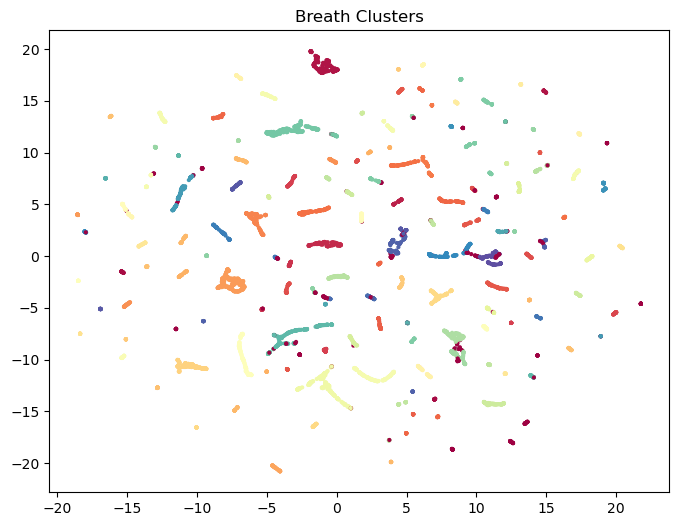

Waveform inspection...


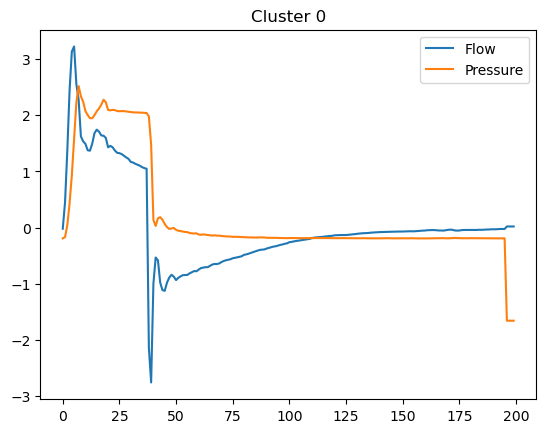

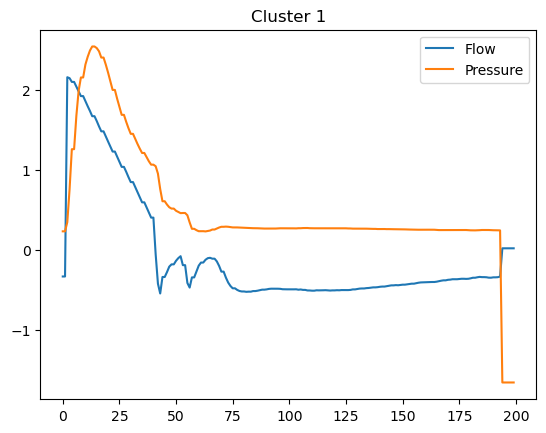

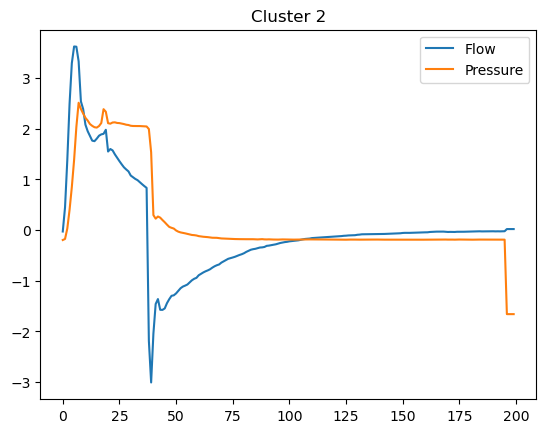

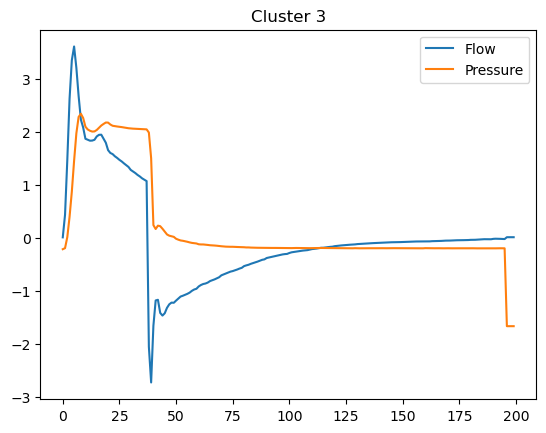

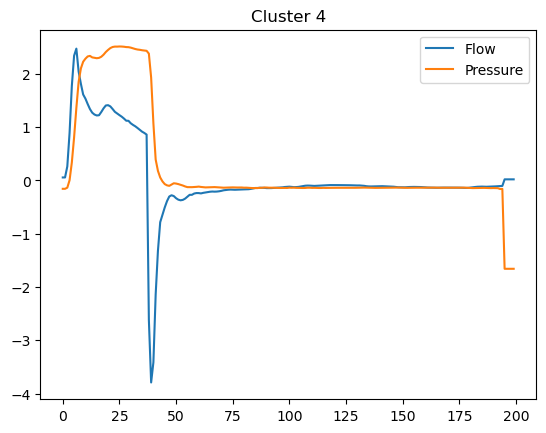

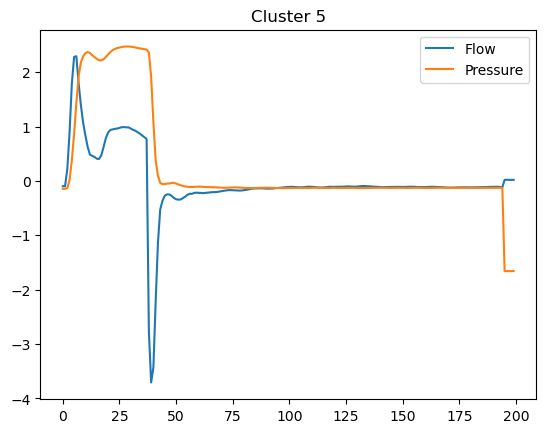

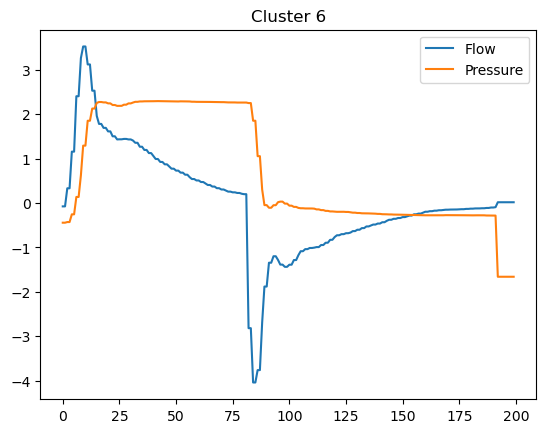

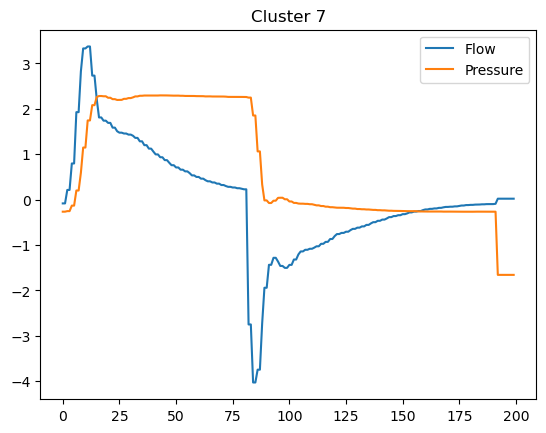

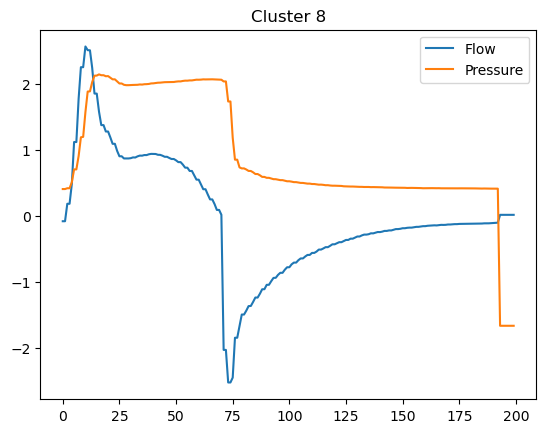

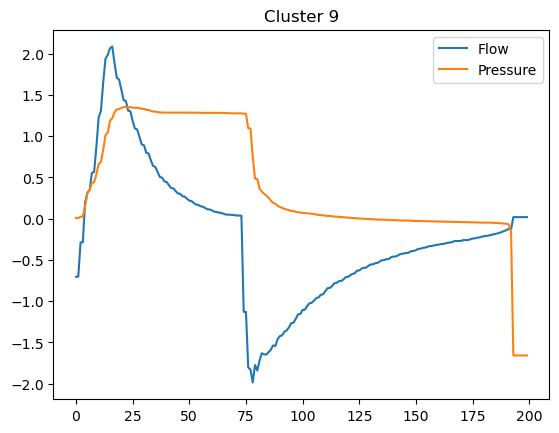

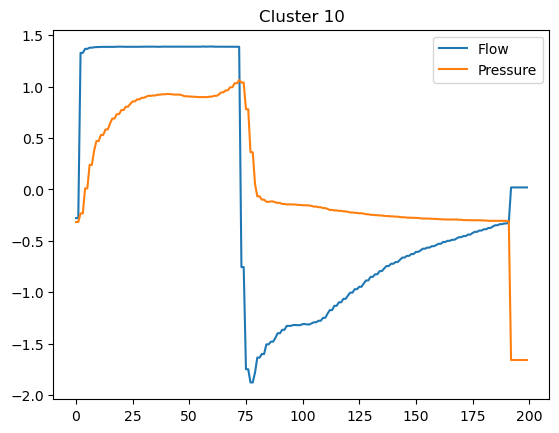

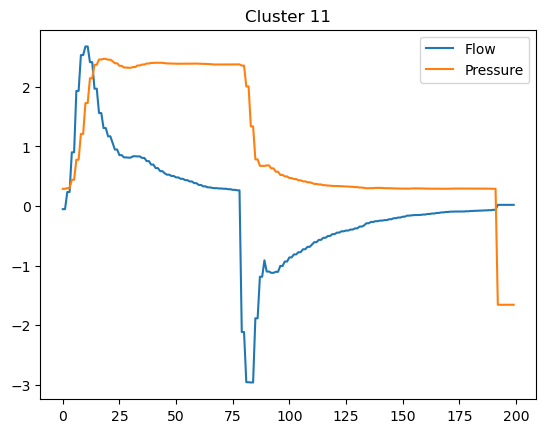

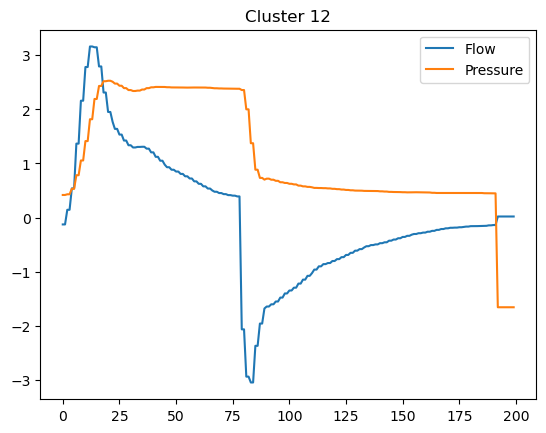

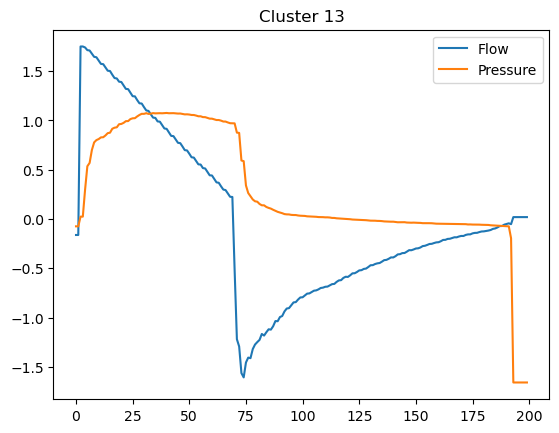

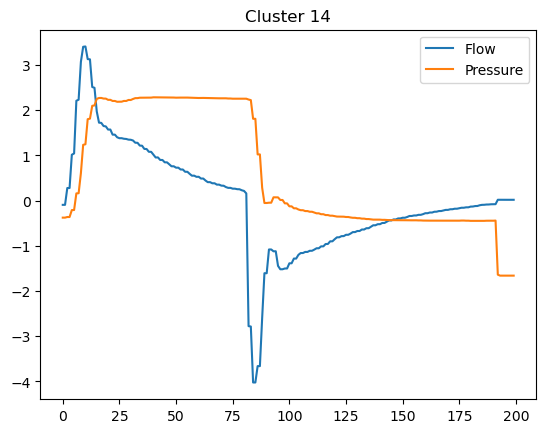

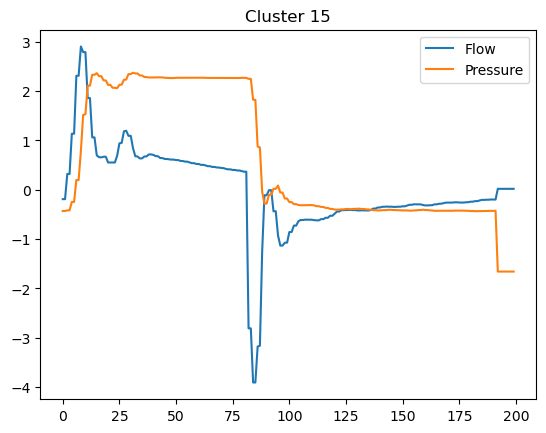

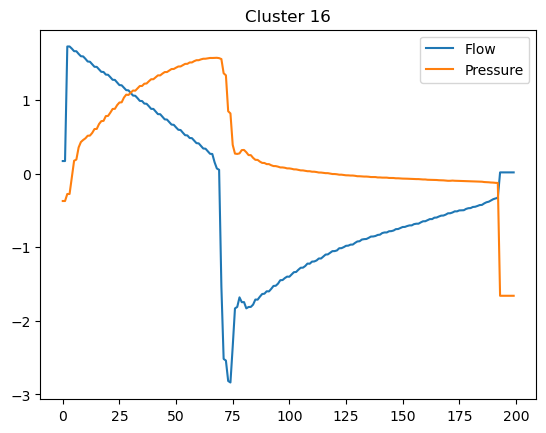

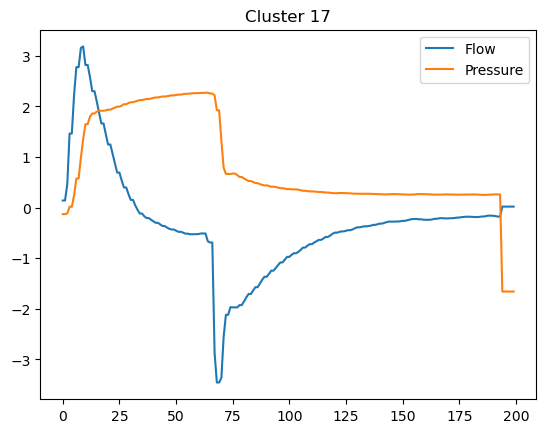

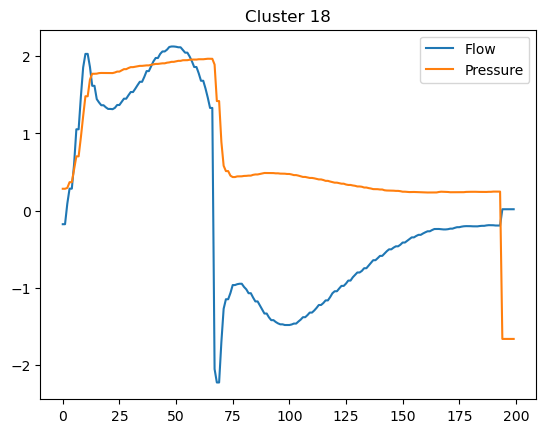

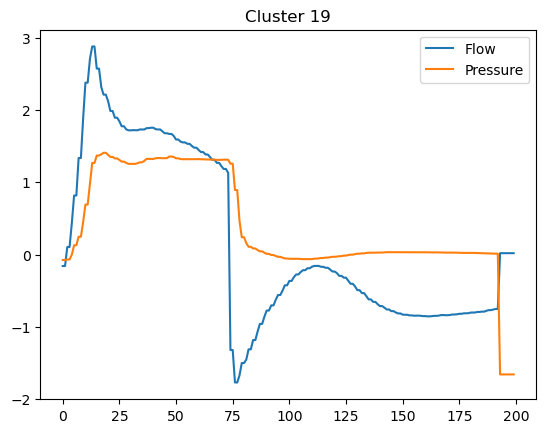

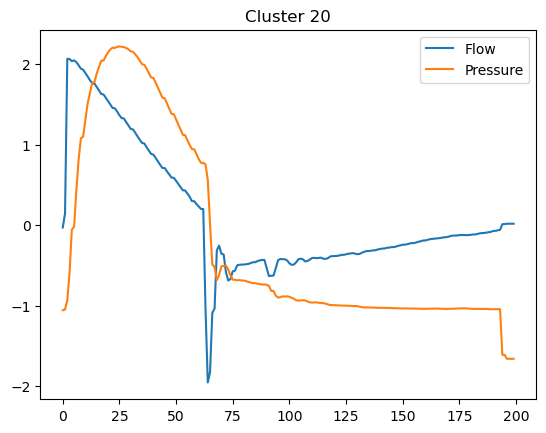

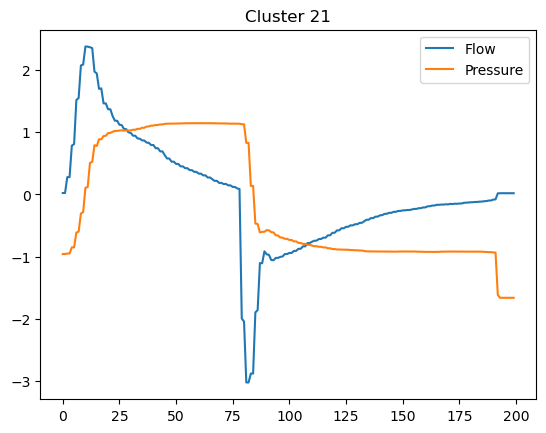

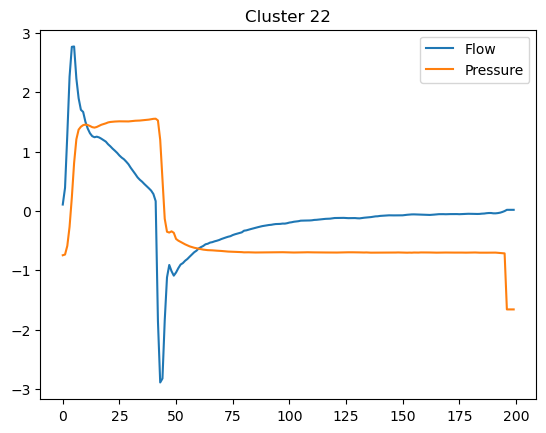

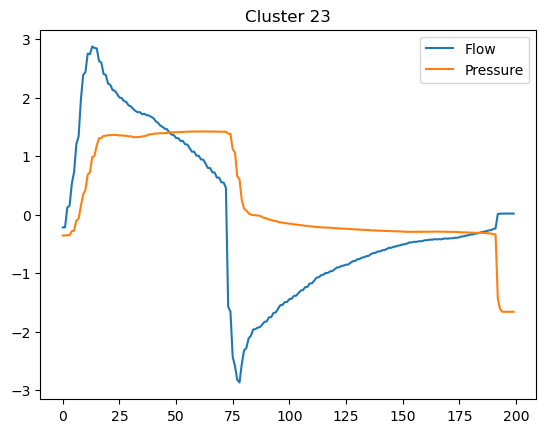

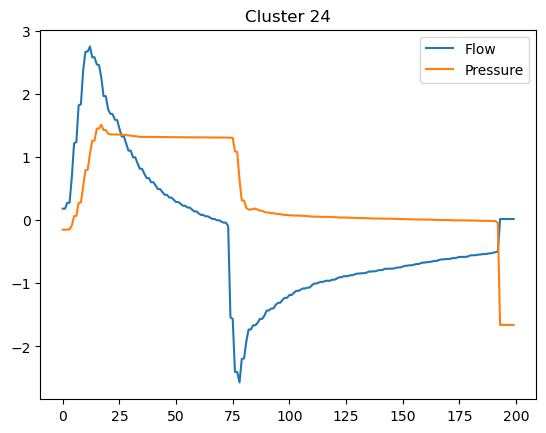

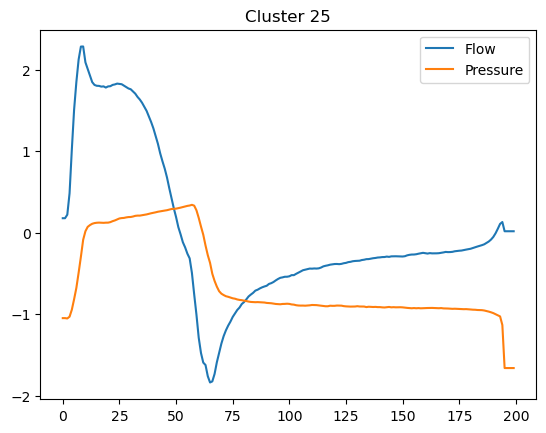

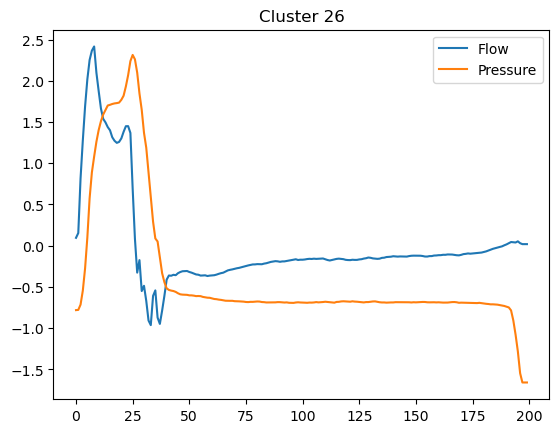

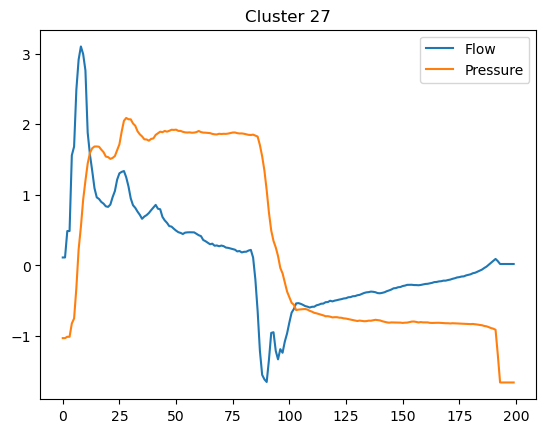

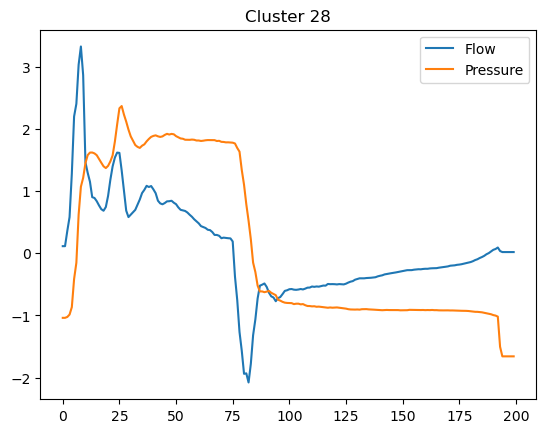

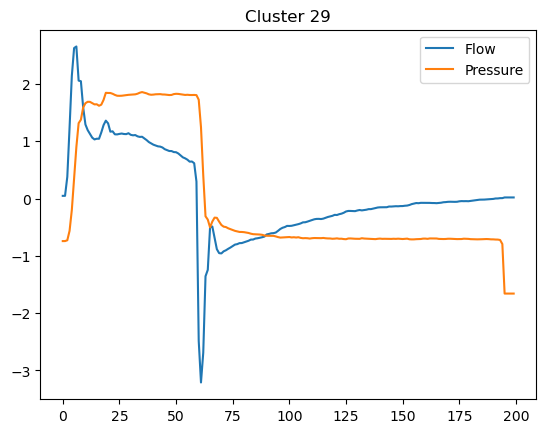

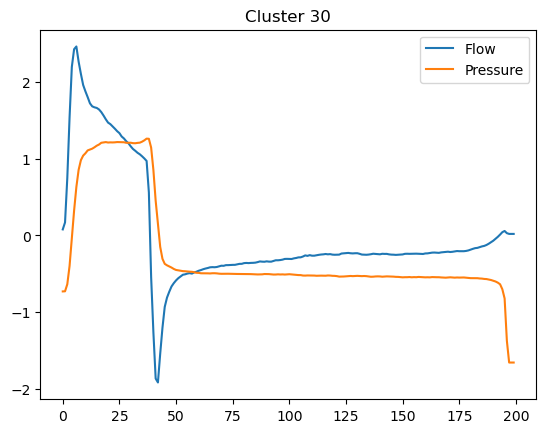

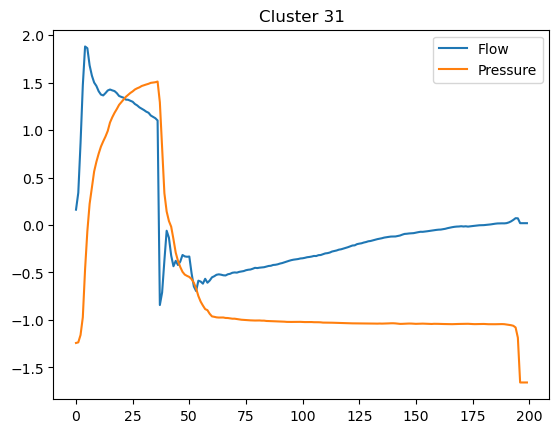

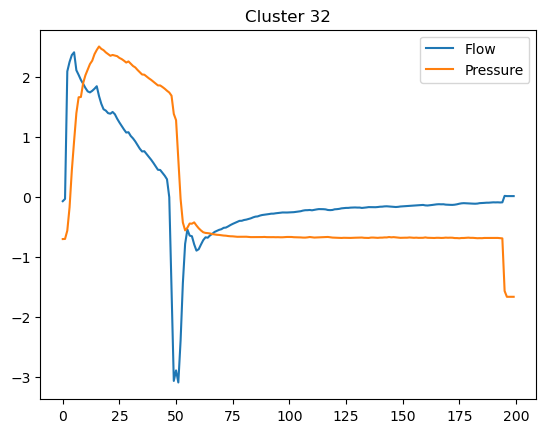

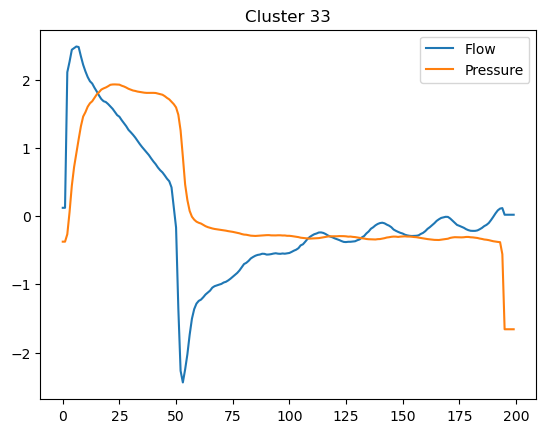

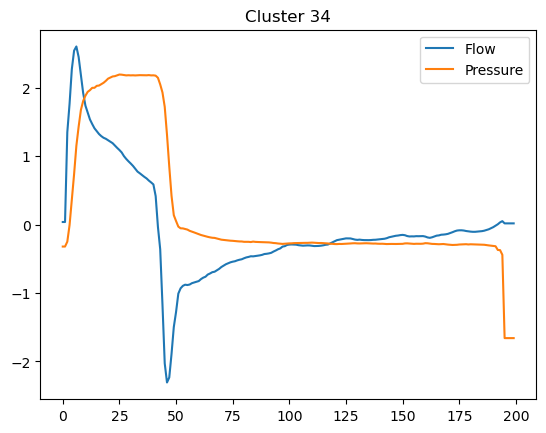

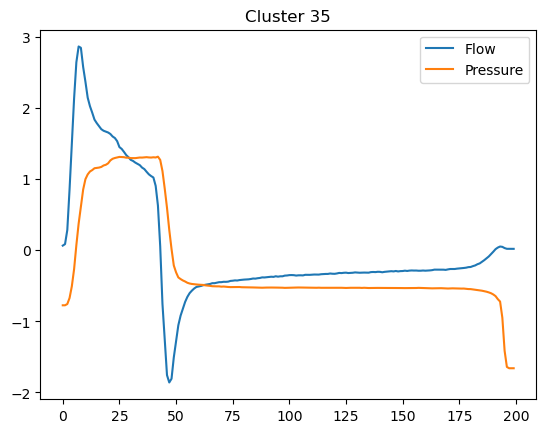

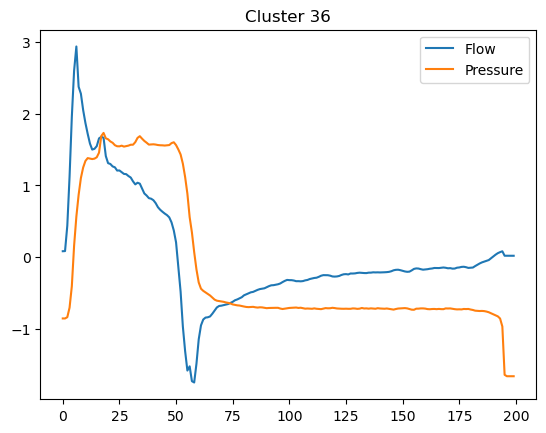

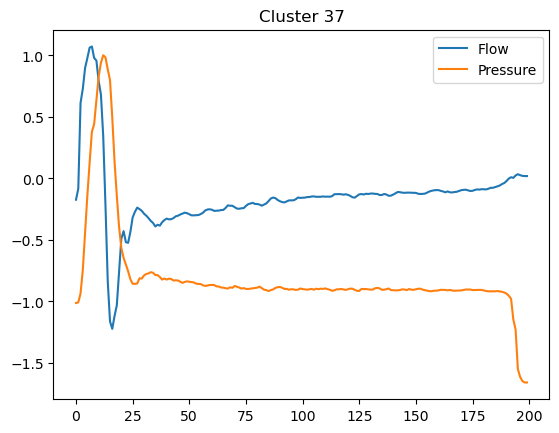

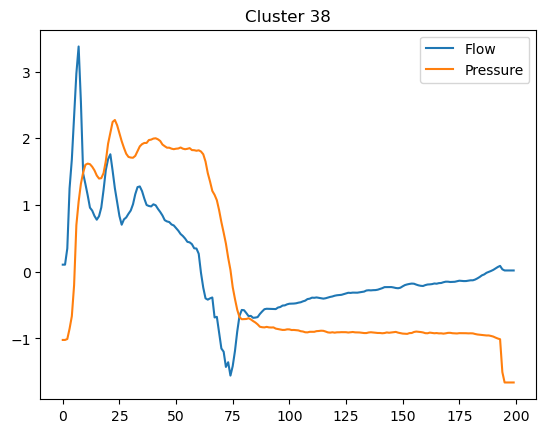

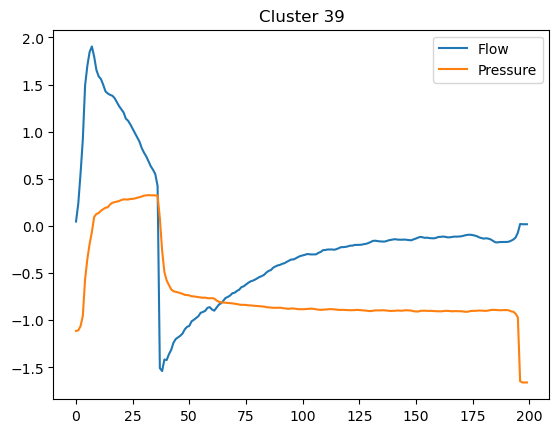

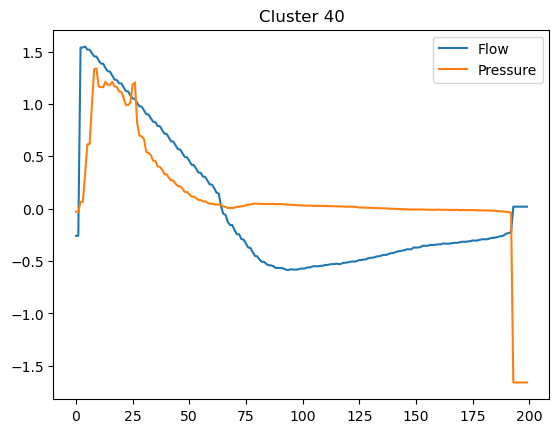

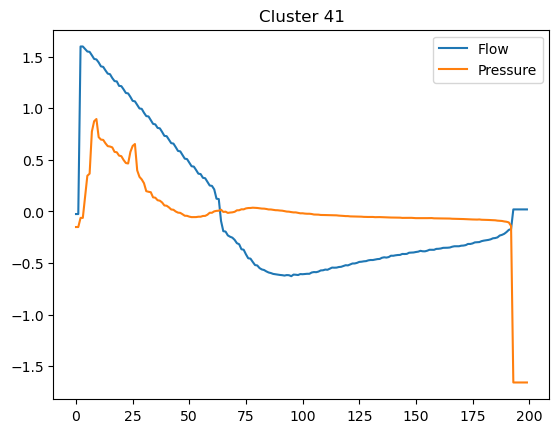

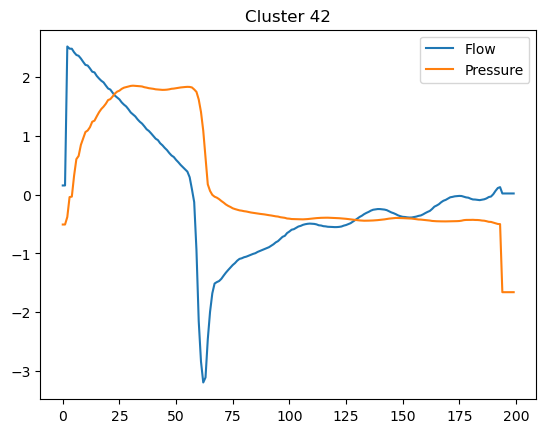

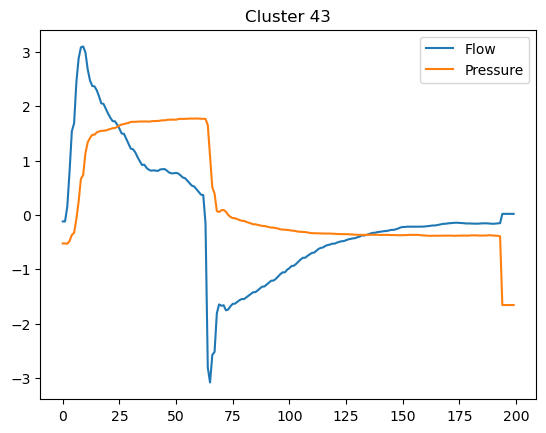

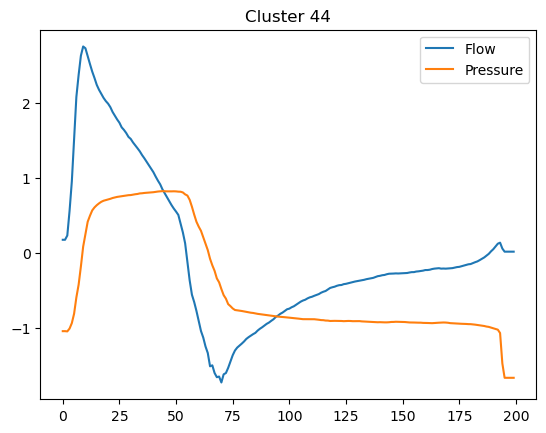

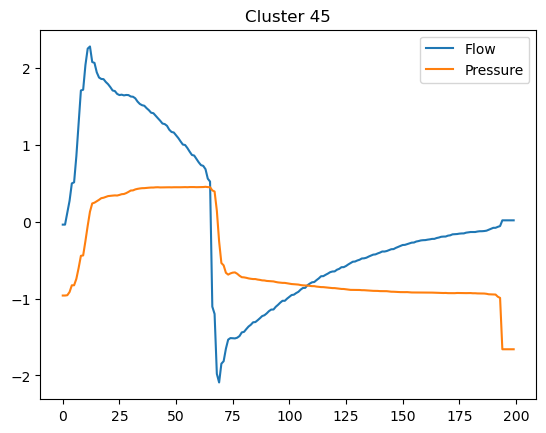

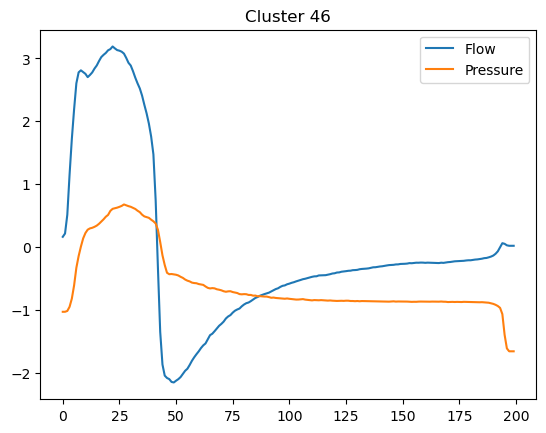

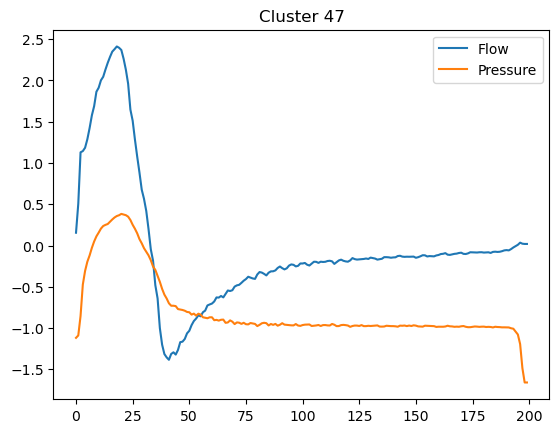

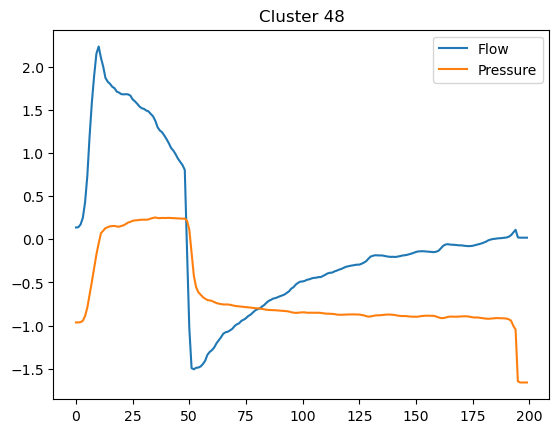

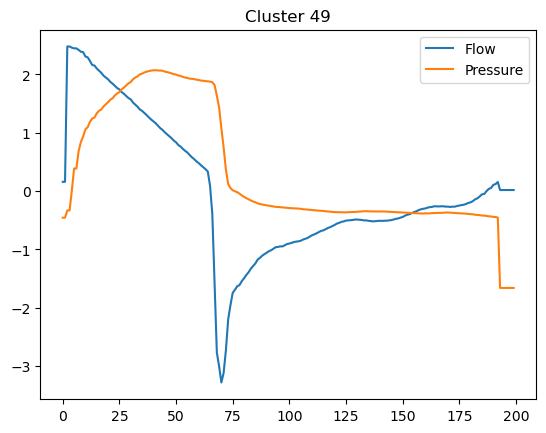

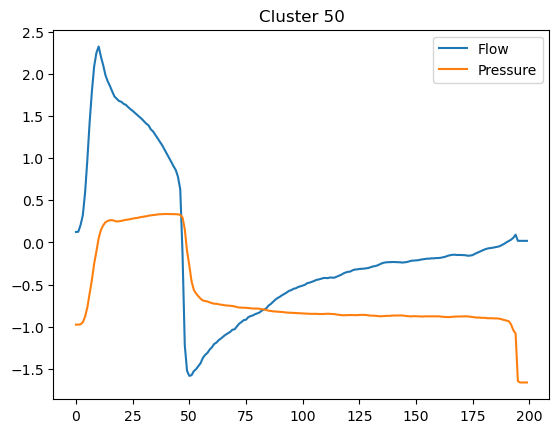

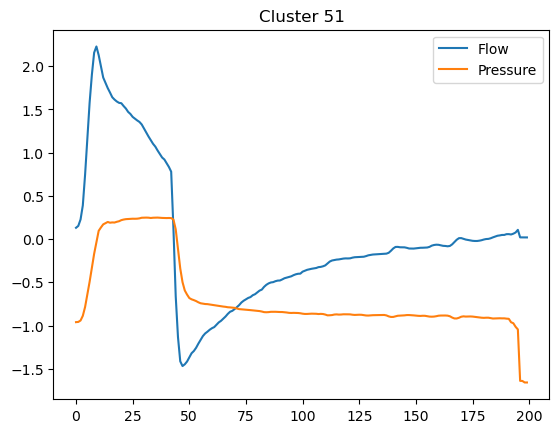

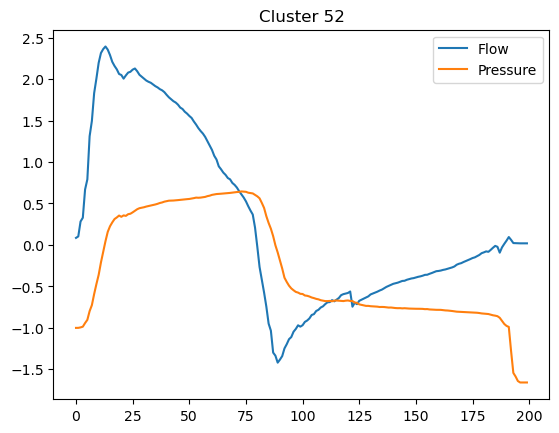

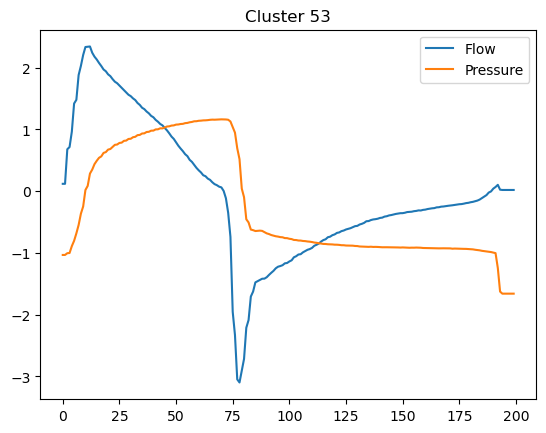

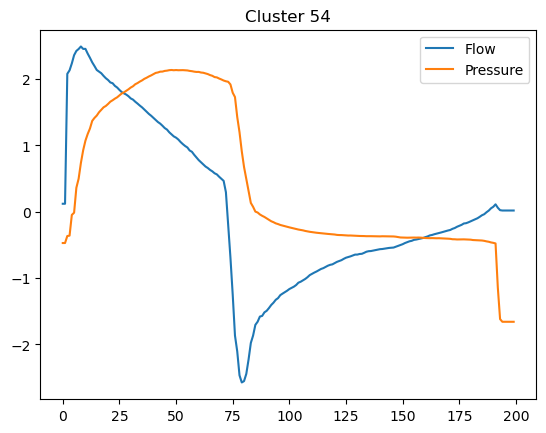

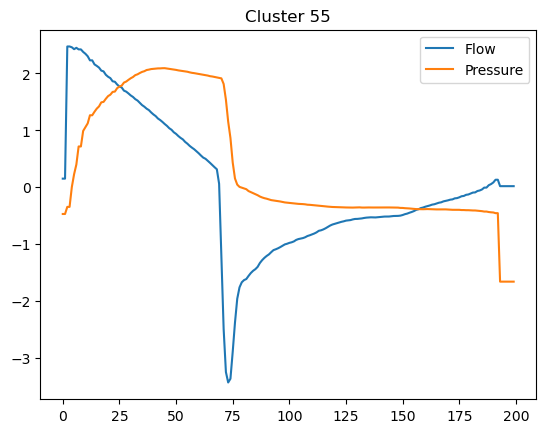

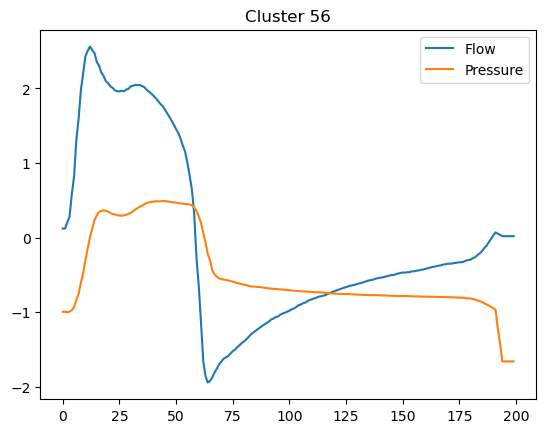

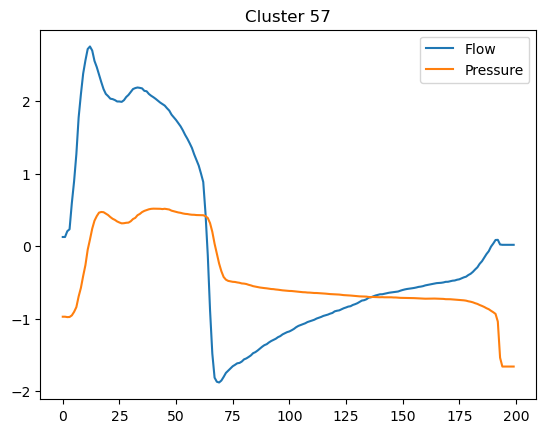

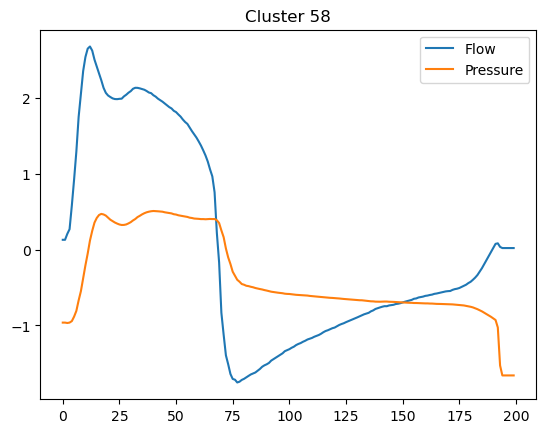

In [46]:
pipeline = DeepBreathClustering(
    target_len=200,
    latent_dim=32,
    epochs=150,
    min_cluster_size=40
)

results = pipeline.run(Dataset)